# Lab 4.7

## 4.7.1 The Stock Market Data

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

[1] 1250    9

      Year           Lag1                Lag2                Lag3          
 Min.   :2001   Min.   :-4.922000   Min.   :-4.922000   Min.   :-4.922000  
 1st Qu.:2002   1st Qu.:-0.639500   1st Qu.:-0.639500   1st Qu.:-0.640000  
 Median :2003   Median : 0.039000   Median : 0.039000   Median : 0.038500  
 Mean   :2003   Mean   : 0.003834   Mean   : 0.003919   Mean   : 0.001716  
 3rd Qu.:2004   3rd Qu.: 0.596750   3rd Qu.: 0.596750   3rd Qu.: 0.596750  
 Max.   :2005   Max.   : 5.733000   Max.   : 5.733000   Max.   : 5.733000  
      Lag4                Lag5              Volume           Today          
 Min.   :-4.922000   Min.   :-4.92200   Min.   :0.3561   Min.   :-4.922000  
 1st Qu.:-0.640000   1st Qu.:-0.64000   1st Qu.:1.2574   1st Qu.:-0.639500  
 Median : 0.038500   Median : 0.03850   Median :1.4229   Median : 0.038500  
 Mean   : 0.001636   Mean   : 0.00561   Mean   :1.4783   Mean   : 0.003138  
 3rd Qu.: 0.596750   3rd Qu.: 0.59700   3rd Qu.:1.6417   3rd Qu.: 0.596750  
 Max. 

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,0.029699649,0.030596422,0.033194581,0.035688718,0.029787995,0.53900647,0.030095229
Lag1,0.02969965,1.000000000,-0.026294328,-0.010803402,-0.002985911,-0.005674606,0.04090991,-0.026155045
Lag2,0.03059642,-0.026294328,1.000000000,-0.025896670,-0.010853533,-0.003557949,-0.04338321,-0.010250033
Lag3,0.03319458,-0.010803402,-0.025896670,1.000000000,-0.024051036,-0.018808338,-0.04182369,-0.002447647
Lag4,0.03568872,-0.002985911,-0.010853533,-0.024051036,1.000000000,-0.027083641,-0.04841425,-0.006899527
Lag5,0.02978799,-0.005674606,-0.003557949,-0.018808338,-0.027083641,1.000000000,-0.02200231,-0.034860083
Volume,0.53900647,0.040909908,-0.043383215,-0.041823686,-0.048414246,-0.022002315,1.00000000,0.014591823
Today,0.03009523,-0.026155045,-0.010250033,-0.002447647,-0.006899527,-0.034860083,0.01459182,1.000000000


The following objects are masked from Smarket (pos = 4):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year




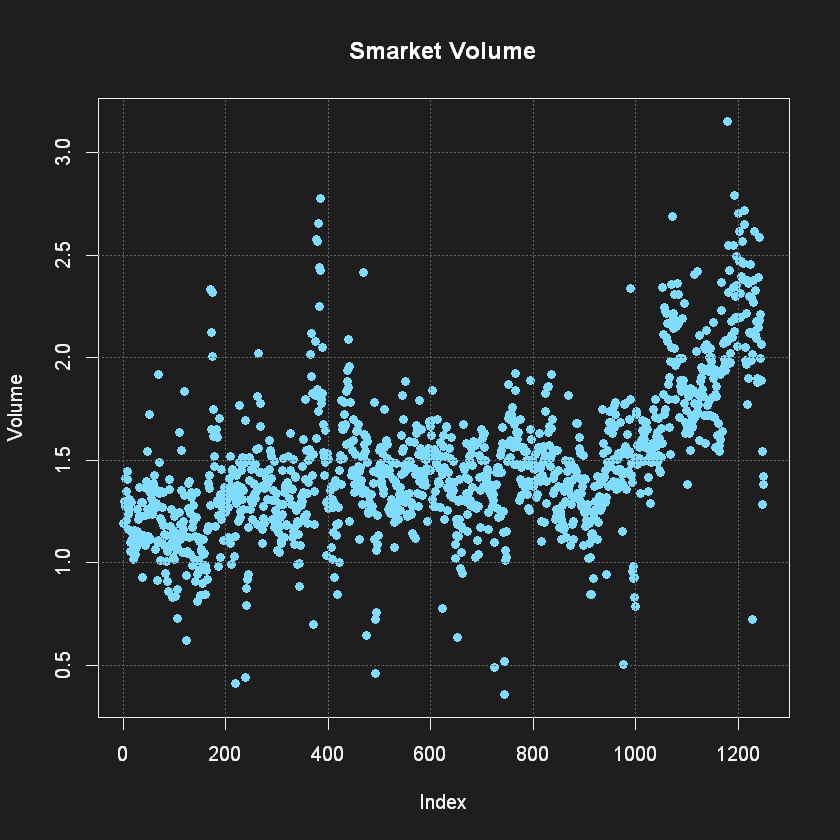

In [25]:
library(ISLR2)
# load library
names(Smarket)
# data set of stockmarket returns for S&P 500 stock index over 1,250 days
# lag1 - lag5 are % returns for 5 previous trading days
#Volume = no of shares traded on previous day
#Today = % return today or day in question
# Direction = whether the market was up or down
dim(Smarket)
#1250 (days) : 9(variables)
summary(Smarket)
cor(Smarket[,-9])
# The cor() function produces a matrix that contains all of the pairwise correlations among the predictors in a data set.You need the [] if var is qualitative
# shows only significant one is year and volume (as volume is inreasing over time and the other days have varied returns day by day)
attach(Smarket)

old_par <- par(no.readonly = TRUE)

par(
  bg = "#1e1e1e",        # plot background
  fg = "#f2f2f2",        # default text/axis color
  col.axis = "#f2f2f2",
  col.lab = "#f2f2f2",
  col.main = "#ffffff"
)

plot(
  Volume,
  col = "#7FDBFF",       # bright points/line
  pch = 19,
  main = "Smarket Volume"
)
grid(col = "#666666")
# Volume (millions) on Y and Index (each data point from 0 to 1250) on X

## 4.7.2 Logistic Regression

predict Direction using Lag1 through Lag5 and Volume

In [26]:
glm.fits <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, 
data = Smarket, family = binomial)
summary(glm.fits)
# The glm() function can be used to fit many types of generalized linear models, including logistic regression. The syntax of the glm() function is similar to that of lm(), except that we must pass in the argument family = binomial in order to tell R to run a logistic regression rather than some other type of generalized linear model.


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3


In [27]:
#The smallest p-value here is associated with Lag1. The negative coefficient for this predictor suggests that if the market had a positive return yesterday,then it is less likely to go up today. However, at a value of 0.15, the p-value is still relatively large, and so there is no clear evidence of a real associationbetween Lag1 and Direction.

# access coefficients for the fitted model
coef(glm.fits)

(Intercept)         Lag1         Lag2         Lag3         Lag4         Lag5 
-0.126000257 -0.073073746 -0.042301344  0.011085108  0.009358938  0.010313068 
      Volume 
 0.135440659

In [28]:
# we can be specific with the summary() function to get the coefficients and p-values
summary(glm.fits)$coef
# the 4th column of the coefficient matrix contains the p-values
summary(glm.fits)$coef[,4]

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-0.126000257,0.24073574,-0.5233966,0.6006983
Lag1,-0.073073746,0.05016739,-1.4565986,0.1452272
Lag2,-0.042301344,0.05008605,-0.8445733,0.3983491
Lag3,0.011085108,0.04993854,0.2219750,0.8243333
Lag4,0.009358938,0.04997413,0.1872757,0.8514445
Lag5,0.010313068,0.04951146,0.2082966,0.8349974
Volume,0.135440659,0.15835970,0.8552723,0.3924004


(Intercept)        Lag1        Lag2        Lag3        Lag4        Lag5 
  0.6006983   0.1452272   0.3983491   0.8243333   0.8514445   0.8349974 
     Volume 
  0.3924004

In [29]:
#predict probabilities of the market going up
#type = "response" gives us the probabilities P(Y=1|X) of the market going up
glm.probs <- predict(glm.fits, type = "response")
round(glm.probs[1:10], 3)
#round 3 to 3 decimal places

1     2     3     4     5     6     7     8     9    10 
0.507 0.481 0.481 0.515 0.511 0.507 0.493 0.509 0.518 0.489

In [30]:
contrasts(Direction)
#shows probabilities of the market going up rather than down as 1 is set to up

,Up
Down,0
Up,1


In [31]:
#The following two commands create a vector of class predictions based on whether the predicted probability of a market increase is greater than or less than 0.5.
glm.pred <- rep("Down", 1250)
glm.pred[glm.probs > .5] <- "Up"
table(glm.pred, Direction)

        Direction
glm.pred Down  Up
    Down  145 141
    Up    457 507

In [32]:
# 145 = predicted Down & actual Down = match
# 141 = predicted Down & actual Up = mismatch
# 457 = predicted Up & actual Down = mismatch
# 507 = predicted Up & actual Up = match

#therefore 507+145 = 652 correct predictions out of 1250 total observations
(507+145)/1250

mean(glm.pred == Direction)
#(gets the same result - 52.2% accuracy)

[1] 0.5216

[1] 0.5216

In [33]:
# Split data: train on years before 2005, test on 2005
train <- (Year < 2005)

# Keep only the 2005 rows (this is the test set)
Smarket.2005 <- Smarket[!train,]

# Check size of test set (should be 252 rows)
dim(Smarket.2005)

# Actual (true) labels for 2005
Direction.2005 <- Direction[!train]

# Fit model using only training rows (before 2005)
glm.fits <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume, 
data = Smarket, family = binomial, subset = train)

# Predict probability of Up for each 2005 day
glm.probs <- predict(glm.fits, Smarket.2005, type = "response")

# Start by predicting Down for every 2005 day
glm.pred <- rep("Down", 252)

# If probability > 0.5, change prediction to Up
glm.pred[glm.probs > .5] <- "Up"

# Compare predicted vs actual (confusion matrix)
table(glm.pred, Direction.2005)

[1] 252   9

        Direction.2005
glm.pred Down Up
    Down   77 97
    Up     34 44

In [34]:
mean(glm.pred == Direction.2005)
# the % right predictions is 48.4% e.g the accuracy
mean(glm.pred != Direction.2005)
# the % wrong predictions is 51.6% e.g the error rate 

[1] 0.4801587

[1] 0.5198413

In [35]:
# the model performs worse than random guessing (which would be 50% accuracy) on the test data, even though it performed slightly better than random guessing on the training data. This is an example of overfitting, where a model fits the training data well but fails to generalize to new data.
# Using predictors that have no relationship with the response tends to cause a deterioration in the test error rate (since such predictors cause an increase in variance without a corresponding decrease in bias). So lets remove them.

glm.fits <- glm(Direction ~ Lag1 + Lag2, data = Smarket, family = binomial, subset = train)
#lag1 and lag2 are the only predictors with p-values less than 0.15, so we will refit the logistic regression model using only these two predictors.

glm.probs <- predict(glm.fits, Smarket.2005, type = "response")
glm.pred <- rep("Down", 252)
glm.pred[glm.probs > .5] <- "Up"
table(glm.pred, Direction.2005)


        Direction.2005
glm.pred Down  Up
    Down   35  35
    Up     76 106

In [36]:
mean(glm.pred == Direction.2005)
#yeilds 56.0% accuracy, which is better than the previous model and random guessing

[1] 0.5595238

In [37]:
106/(106+76)
# taken from the up predictions, yeilds a similar result of 58.3% accuracy, which is better than the previous model and random guessing and would suggest that the model is better at predicting when the market will go up than when it will go down, but this could be chance.

[1] 0.5824176

In [38]:
#lets predict some exact values, say lag1 at 1.2 and lag2 at 1.1, which are the values for the first row of the data set
predict(glm.fits, newdata = data.frame(Lag1 = 1.2, Lag2 = 1.1), type = "response")

predict(glm.fits, newdata = data.frame(Lag1 = 1.5, Lag2 = -0.8), type = "response")

#also can be written altogether as
predict(glm.fits, newdata = data.frame(Lag1 = c(1.2, 1.5), Lag2 = c(1.1, -0.8)), type = "response")

1 
0.4791462

1 
0.4960939

1         2 
0.4791462 0.4960939

## 4.7.3 Linear Discriminant Analysis

In [39]:
# lda(), part of the MASS library, is identical to the lm() function and glm() without the family option
# again we'll fit using obsrv before 2005 and test on 2005

library(MASS)
lda.fit <- lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)
lda.fit


Call:
lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

Coefficients of linear discriminants:
            LD1
Lag1 -0.6420190
Lag2 -0.5135293

In [40]:
#indicates that ˆπ1 = 0.492 and ˆπ2 = 0.508; in other words, 49.2 % of the training observations correspond to days during which the market went down
#ˆπ1 and ˆπ2 are the prior probabilities of class.
# there is a tendency for the previous 2 days’ returns to be negative on days when the market increases, and a tendency for the previous days’ returns to be positive on days when the market declines

#for LD1
#If −0.642×Lag1 − 0.514×Lag2 is large, then the LDA classifier will predict a market increase, and if it is small, then the LDA classifier will predict a market decline.

lda.pred <- predict(lda.fit, Smarket.2005)
names(lda.pred)

[1] "class"     "posterior" "x"

In [41]:
#'class' contains the LDA predictions for each observation in the test set
#'posterior' contains the posterior probabilities for each class, in a matrix with two columns, one for each class
#'x' contains the linear discriminants for each observation

lda.class <- lda.pred$class
table(lda.class, Direction.2005)

         Direction.2005
lda.class Down  Up
     Down   35  35
     Up     76 106

In [42]:
# almost identical to the logistic regression model:
#        Direction.2005
#glm.pred Down  Up
#    Down   35  35
#    Up     76 106

#apply a 50% threshold to the posterior probabilities to produce class predictions
sum(lda.pred$posterior[,1] >= 0.5) #70 observations are predicted "Down"
sum(lda.pred$posterior[,1] < 0.5) # 182 observations are predicted "Up"

# 70 : 182 ratio is demonstrated here:
lda.pred$posterior[1:20,1]
lda.class[1:20]

[1] 70

[1] 182

999      1000      1001      1002      1003      1004      1005      1006 
0.4901792 0.4792185 0.4668185 0.4740011 0.4927877 0.4938562 0.4951016 0.4872861 
     1007      1008      1009      1010      1011      1012      1013      1014 
0.4907013 0.4844026 0.4906963 0.5119988 0.4895152 0.4706761 0.4744593 0.4799583 
     1015      1016      1017      1018 
0.4935775 0.5030894 0.4978806 0.4886331

[1] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Down Up   Up   Up  
[16] Up   Up   Down Up   Up  
Levels: Down Up

In [43]:
# lets try a 90% threshold instead of 50%
sum(lda.pred$posterior[,1] >= 0.9) # gets 0 therefore no days in 2005 meet the threshold

[1] 0

## 4.7.4 Quadratic Disriminant Analysis

In [44]:
#next a QDA model
qda.fit <- qda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)
qda.fit

Call:
qda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

In [45]:
# doesn't contain coefficients bc its quadratic, not linear

qda.class <- predict(qda.fit, Smarket.2005)$class
table(qda.class, Direction.2005)

         Direction.2005
qda.class Down  Up
     Down   30  20
     Up     81 121

In [46]:
mean(qda.class == Direction.2005)
#yeilds almost 60% so suggests QDA captures the relationship the most accurately

[1] 0.5992063

## 4.7.5 Naive Bayes

In [48]:
library(e1071)
nb.fit <- naiveBayes(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)
nb.fit

Warning message:
"package 'e1071' was built under R version 4.5.3"



Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
    Down       Up 
0.491984 0.508016 

Conditional probabilities:
      Lag1
Y             [,1]     [,2]
  Down  0.04279022 1.227446
  Up   -0.03954635 1.231668

      Lag2
Y             [,1]     [,2]
  Down  0.03389409 1.239191
  Up   -0.03132544 1.220765


In [51]:
#^ ,1 is the mean and ,2 is the standard deviation
round(mean(Lag1[train][Direction[train] == "Down"]),2)
round(sd(Lag1[train][Direction[train] == "Down"]),2)

[1] 0.04

[1] 1.23

In [59]:
# the predict function is also straight forward
nb.class <- predict(nb.fit, Smarket.2005)
table(nb.class, Direction.2005)

cat("Mean: ", round(mean(nb.class == Direction.2005), 3), "\n", sep = "")

        Direction.2005
nb.class Down  Up
    Down   28  20
    Up     83 121

Mean: 0.591


In [ ]:
# again performs very well, almost 60%

#The predict() function can also generate estimates of the probability that each observation belongs to a particular class.
nb.preds<- predict(nb.fit, Smarket.2005, type = "raw")
nb.preds[1:5,]

Down,Up
0.4873164,0.5126836
0.4762492,0.5237508
0.4653377,0.5346623
0.4748652,0.5251348
0.4901890,0.5098110


## 4.7.6 K-Nearest Neighbors

In [ ]:
# The KNN function requires four inputs.
# 1. A matrix containing the predictors associated with the training data, labeled train.X below.
# 2. A matrix containing the predictors associated with the data for which we wish to make predictions, labeled test.X below.
# 3. A vector containing the class labels for the training observations, labeled train.Direction below.
# 4. A value for K, the number of nearest neighbors to be used by the classifier.

library(class)
train.X <- cbind(Lag1, Lag2)[train,]
# column bind (cbind) binds the lag1 and lag2 predictors together into a matrix, and the [train,] selects only the training observations (those from before 2005).
test.X <- cbind(Lag1, Lag2)[!train,]
train.Direction <- Direction[train]
# we set a random seed before running the knn() function in order to ensure that we obtain the same results as we run the code multiple times
set.seed(1)
knn.pred <- knn(train.X, test.X, train.Direction, k = 1)
table(knn.pred, Direction.2005)

mean(knn.pred == Direction.2005)
# AKA
(83+43)/252
#Yeilds 50% accuracy

        Direction.2005
knn.pred Down Up
    Down   43 58
    Up     68 83

[1] 0.5

[1] 0.5

In [68]:
# lets try k = 3
knn.pred <- knn(train.X, test.X, train.Direction, k = 3)
table(knn.pred, Direction.2005)
mean(knn.pred == Direction.2005)

        Direction.2005
knn.pred Down Up
    Down   48 54
    Up     63 87

[1] 0.5357143

In [72]:
# KNN responds significantly to the scale of the predictors, so we will standardize the two predictors to have mean zero and standard deviation one before running KNN. We will use the scale() function to standardize the data.
dim(Caravan)
attach(Caravan)

standardized.X <- scale(Caravan[, -86]) #exclude column 86 as its a qualitative variable
var(Caravan[,1])
var(Caravan[,2])
var(standardized.X[,1])
var(standardized.X[,2])

[1] 5822   86

The following objects are masked from Caravan (pos = 3):

    AAANHANG, ABESAUT, ABRAND, ABROM, ABYSTAND, AFIETS, AGEZONG,
    AINBOED, ALEVEN, AMOTSCO, APERSAUT, APERSONG, APLEZIER, ATRACTOR,
    AVRAAUT, AWABEDR, AWALAND, AWAOREG, AWAPART, AWERKT, AZEILPL,
    MAANTHUI, MAUT0, MAUT1, MAUT2, MBERARBG, MBERARBO, MBERBOER,
    MBERHOOG, MBERMIDD, MBERZELF, MFALLEEN, MFGEKIND, MFWEKIND,
    MGEMLEEF, MGEMOMV, MGODGE, MGODOV, MGODPR, MGODRK, MHHUUR, MHKOOP,
    MINK123M, MINK3045, MINK4575, MINK7512, MINKGEM, MINKM30, MKOOPKLA,
    MOPLHOOG, MOPLLAAG, MOPLMIDD, MOSHOOFD, MOSTYPE, MRELGE, MRELOV,
    MRELSA, MSKA, MSKB1, MSKB2, MSKC, MSKD, MZFONDS, MZPART, PAANHANG,
    PBESAUT, PBRAND, PBROM, PBYSTAND, PFIETS, PGEZONG, PINBOED, PLEVEN,
    PMOTSCO, PPERSAUT, PPERSONG, PPLEZIER, PTRACTOR, Purchase, PVRAAUT,
    PWABEDR, PWALAND, PWAOREG, PWAPART, PWERKT, PZEILPL




The following objects are masked from Caravan (pos = 4):

    AAANHANG, ABESAUT, ABRAND, ABROM, ABYSTAND, AFIETS, AGEZONG,
    AINBOED, ALEVEN, AMOTSCO, APERSAUT, APERSONG, APLEZIER, ATRACTOR,
    AVRAAUT, AWABEDR, AWALAND, AWAOREG, AWAPART, AWERKT, AZEILPL,
    MAANTHUI, MAUT0, MAUT1, MAUT2, MBERARBG, MBERARBO, MBERBOER,
    MBERHOOG, MBERMIDD, MBERZELF, MFALLEEN, MFGEKIND, MFWEKIND,
    MGEMLEEF, MGEMOMV, MGODGE, MGODOV, MGODPR, MGODRK, MHHUUR, MHKOOP,
    MINK123M, MINK3045, MINK4575, MINK7512, MINKGEM, MINKM30, MKOOPKLA,
    MOPLHOOG, MOPLLAAG, MOPLMIDD, MOSHOOFD, MOSTYPE, MRELGE, MRELOV,
    MRELSA, MSKA, MSKB1, MSKB2, MSKC, MSKD, MZFONDS, MZPART, PAANHANG,
    PBESAUT, PBRAND, PBROM, PBYSTAND, PFIETS, PGEZONG, PINBOED, PLEVEN,
    PMOTSCO, PPERSAUT, PPERSONG, PPLEZIER, PTRACTOR, Purchase, PVRAAUT,
    PWABEDR, PWALAND, PWAOREG, PWAPART, PWERKT, PZEILPL


The following objects are masked from Caravan (pos = 5):

    AAANHANG, ABESAUT, ABRAND, ABROM, ABYSTAND, AFIETS, AGEZONG,
    

[1] 165.0378

[1] 0.1647078

[1] 1

[1] 1

In [ ]:
test <- 1:1000
train.X <- standardized.X[-test, ]
test.X <- standardized.X[test, ]
train.Y <- Purchase[-test]
test.Y <- Purchase[test]
set.seed(1)
knn.pred <- knn(train.X, test.X, train.Y, k = 1)
mean(test.Y != knn.pred)
mean(test.Y != "No")
#Yeilds a 12% error rate which seems good but since only 6% of customers purchase the caravan insurance, we could get an error rate of 6% by simply predicting that no one will purchase the insurance.

[1] 0.118

[1] 0.059

In [76]:
# K=1 does well at predicting which customers are likely to purchase the caravan insurance, so could save resources by only contacting those customers
table(knn.pred , test.Y)

        test.Y
knn.pred  No Yes
     No  873  50
     Yes  68   9

## 4.7.7 Poisson Regression

In [80]:
attach(Bikeshare)
dim(Bikeshare)
names(Bikeshare)

The following objects are masked from Bikeshare (pos = 3):

    atemp, bikers, casual, day, holiday, hr, hum, mnth, registered,
    season, temp, weathersit, weekday, windspeed, workingday


The following objects are masked from Bikeshare (pos = 4):

    atemp, bikers, casual, day, holiday, hr, hum, mnth, registered,
    season, temp, weathersit, weekday, windspeed, workingday


The following objects are masked from Bikeshare (pos = 5):

    atemp, bikers, casual, day, holiday, hr, hum, mnth, registered,
    season, temp, weathersit, weekday, windspeed, workingday




[1] 8645   15

[1] "season"     "mnth"       "day"        "hr"         "holiday"   
 [6] "weekday"    "workingday" "weathersit" "temp"       "atemp"     
[11] "hum"        "windspeed"  "casual"     "registered" "bikers"

In [ ]:
#least squares linear regression model to predict the number of bikers based on the month, hour, working day, temperature and weather situation
mod.lm <- lm(bikers ~mnth + hr + workingday + temp + weathersit,
data= Bikeshare)
summary(mod.lm)


Call:
lm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    data = Bikeshare)

Residuals:
    Min      1Q  Median      3Q     Max 
-299.00  -45.70   -6.23   41.08  425.29 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                -68.632      5.307 -12.932  < 2e-16 ***
mnthFeb                      6.845      4.287   1.597 0.110398    
mnthMarch                   16.551      4.301   3.848 0.000120 ***
mnthApril                   41.425      4.972   8.331  < 2e-16 ***
mnthMay                     72.557      5.641  12.862  < 2e-16 ***
mnthJune                    67.819      6.544  10.364  < 2e-16 ***
mnthJuly                    45.324      7.081   6.401 1.63e-10 ***
mnthAug                     53.243      6.640   8.019 1.21e-15 ***
mnthSept                    66.678      5.925  11.254  < 2e-16 ***
mnthOct                     75.834      4.950  15.319  < 2e-16 ***
mnthNov                     60.310      4.610  13.083  < 2

In [83]:
#Jan doesn't appear as it's treated as the baseline values
# we can interpret that there's an avg of 6 more riders in feb than jan or 16 more in march than jan
contrasts(Bikeshare$hr) = contr.sum(24)
contrasts(Bikeshare$mnth) = contr.sum(12)
mod.lm2 <- lm(bikers ~mnth + hr + workingday + temp + weathersit,
data= Bikeshare)
summary(mod.lm2)


Call:
lm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    data = Bikeshare)

Residuals:
    Min      1Q  Median      3Q     Max 
-299.00  -45.70   -6.23   41.08  425.29 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 73.5974     5.1322  14.340  < 2e-16 ***
mnth1                      -46.0871     4.0855 -11.281  < 2e-16 ***
mnth2                      -39.2419     3.5391 -11.088  < 2e-16 ***
mnth3                      -29.5357     3.1552  -9.361  < 2e-16 ***
mnth4                       -4.6622     2.7406  -1.701  0.08895 .  
mnth5                       26.4700     2.8508   9.285  < 2e-16 ***
mnth6                       21.7317     3.4651   6.272 3.75e-10 ***
mnth7                       -0.7626     3.9084  -0.195  0.84530    
mnth8                        7.1560     3.5347   2.024  0.04295 *  
mnth9                       20.5912     3.0456   6.761 1.46e-11 ***
mnth10                      29.7472     2.6995 

In [ ]:
#the difference in the data here is instead of jan being the baseline, the baseline is now the average of all months, so we can interpret that there's an avg of 46 less riders in jan than the average month or 26 more in may than the average month

round(sum((predict(mod.lm) - predict(mod.lm2))^2),3)
# comparing the prediction from the two models we can see that the sum of the squared difference is 0 meaning it doesn't matter which way we encode the variables, just how we interpret the coefficients

[1] 0

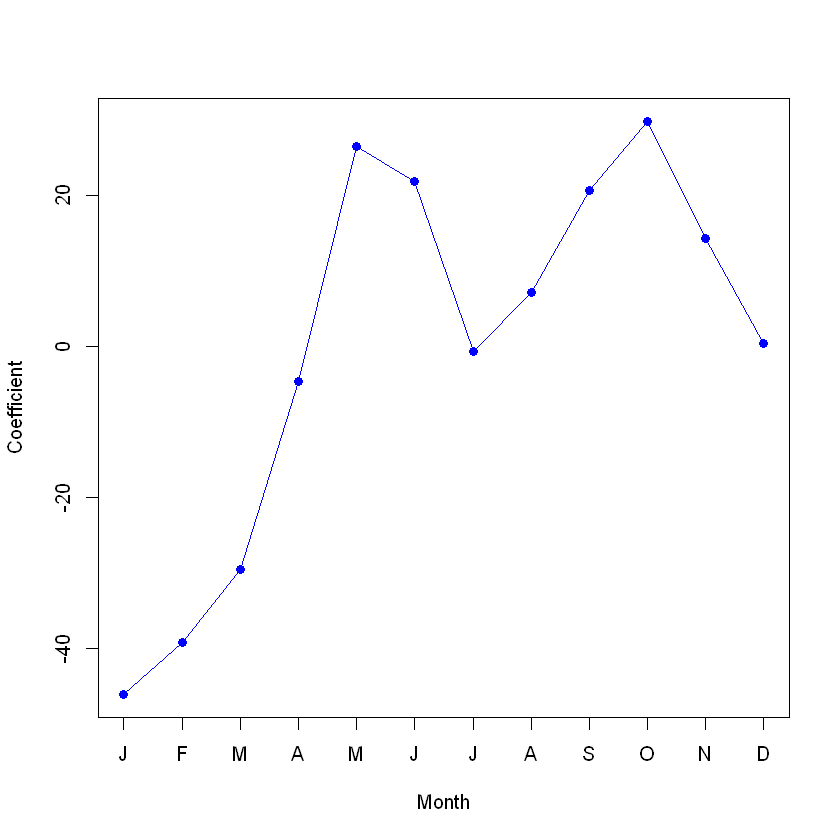


Call:
glm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    family = poisson, data = Bikeshare)

Coefficients:
                           Estimate Std. Error  z value Pr(>|z|)    
(Intercept)                4.118245   0.006021  683.964  < 2e-16 ***
mnth1                     -0.670170   0.005907 -113.445  < 2e-16 ***
mnth2                     -0.444124   0.004860  -91.379  < 2e-16 ***
mnth3                     -0.293733   0.004144  -70.886  < 2e-16 ***
mnth4                      0.021523   0.003125    6.888 5.66e-12 ***
mnth5                      0.240471   0.002916   82.462  < 2e-16 ***
mnth6                      0.223235   0.003554   62.818  < 2e-16 ***
mnth7                      0.103617   0.004125   25.121  < 2e-16 ***
mnth8                      0.151171   0.003662   41.281  < 2e-16 ***
mnth9                      0.233493   0.003102   75.281  < 2e-16 ***
mnth10                     0.267573   0.002785   96.091  < 2e-16 ***
mnth11                     0.150264   0.00

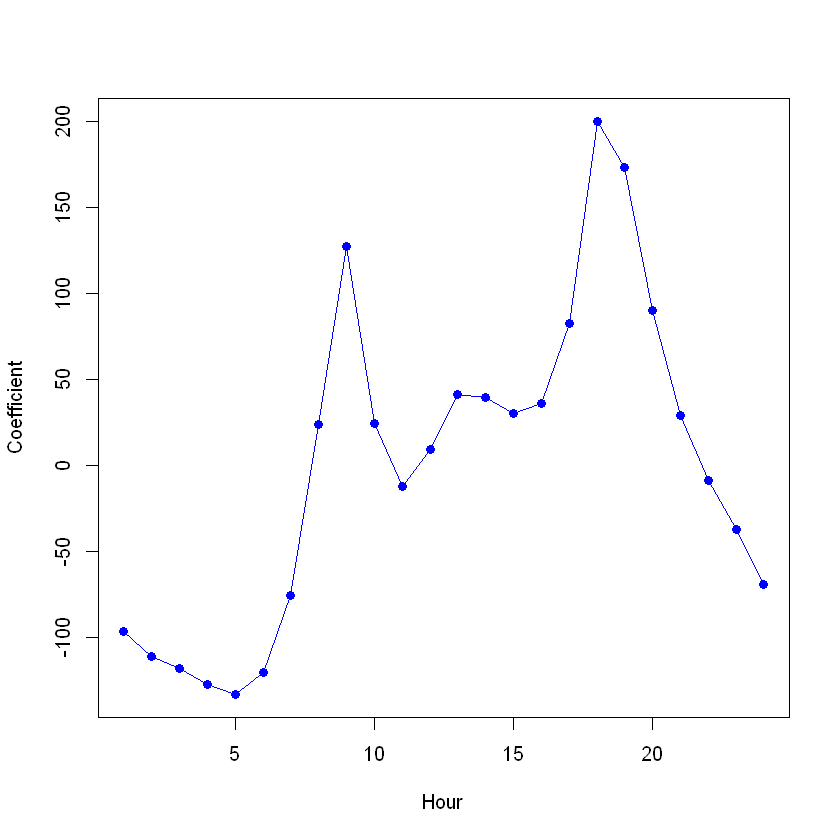

In [92]:
#The coefficient for December must be explicitly computed as the negative sum of all the other months.
coef.months <- c(coef(mod.lm2)[2:12], -sum(coef(mod.lm2)[2:12]))


#plot the left figure with x-axis as months:
plot(coef.months, xlab = "Month", ylab = "Coefficient", xaxt = "n", col = "blue", pch = 19, type = "o")
axis(side = 1, at = 1:12, labels = c("J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"))
#plot the right figure with x-axis as hours:
coef.hours <- c(coef(mod.lm2)[13:35], -sum(coef(mod.lm2)[13:35]))
plot(coef.hours, xlab = "Hour", ylab = "Coefficient", col = "blue", pch = 19, type = "o")

mod.pois <- glm(bikers ~mnth + hr + workingday + temp + weathersit,
data= Bikeshare, family = poisson)
summary(mod.pois)

In [ ]:
#We can once again use the predict() function to obtain the fitted values (predictions) from this Poisson regression model. However, we must use the argument type = "response" to specify that we want R to output exp( ˆ β0 + ˆ β1X1+. . .+ ˆ βpXp) rather than ˆ β0+ ˆ β1X1+. . .+ ˆ βpXp, which it will output by default.

## 4.8 Exercises

-- page 200 --

1. Using a little bit of algebra, prove that (4.2) is equivalent to (4.3). In
other words, the logistic function representation and logit representation
for the logistic regression model are equivalent.

2. It was stated in the text that classifying an observation to the class
for which (4.17) is largest is equivalent to classifying an observation
to the class for which (4.18) is largest. Prove that this is the case. In
other words, under the assumption that the observations in the kth
class are drawn from a N(μk, σ2) distribution, the Bayes classifier
assigns an observation to the class for which the discriminant function
is maximized.

3. This problem relates to the QDA model, in which the observations
within each class are drawn from a normal distribution with a classspecific
mean vector and a class specific covariance matrix. We consider
the simple case where p = 1; i.e. there is only one feature.
Suppose that we have K classes, and that if an observation belongs
to the kth class then X comes from a one-dimensional normal distribution,
X ∼ N(μk, σ2
k). Recall that the density function for the
one-dimensional normal distribution is given in (4.16). Prove that in
this case, the Bayes classifier is not linear. Argue that it is in fact
quadratic.
Hint: For this problem, you should follow the arguments laid out in
Section 4.4.1, but without making the assumption that σ2
1 = . . . = σ2K
.

6. Suppose we collect data for a group of students in a statistics class
with variables X1 = hours studied, X2 = undergrad GPA, and Y =
receive an A. We fit a logistic regression and produce estimated
coefficient, ˆ β0 = −6, ˆ β1 = 0.05, ˆ β2 = 1.
(a) Estimate the probability that a student who studies for 40 h and
has an undergrad GPA of 3.5 gets an A in the class.
(b) How many hours would the student in part (a) need to study to
have a 50 % chance of getting an A in the class?

8. Suppose that we take a data set, divide it into equally-sized training
and test sets, and then try out two different classification procedures.
First we use logistic regression and get an error rate of 20 % on the
training data and 30 % on the test data. Next we use 1-nearest neighbors
(i.e. K = 1) and get an average error rate (averaged over both
test and training data sets) of 18 %. Based on these results, which
method should we prefer to use for classification of new observations?
Why?

13. This question should be answered using the Weekly data set, which
is part of the ISLR2 package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of 2010

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?
(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to bestatistically significant? If so,
which ones?
(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.
(d) Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).
(h) Repeat (d) using naive Bayes.